# HealthConnect Clinic — Week 8 Final Analytics & Decision Support Package
**AnalystLab Africa Experience Lab | Data Analytics Track | Simbarashe Mandiveyi**

This notebook is the final output of the Data Analytics track's work across the HealthConnect Experience Lab. It consolidates — rather than repeats — the work completed in Weeks 5 through 7 into one authoritative final analysis: final KPIs, validated findings, a final decision-support dashboard, business insights, recommendations, limitations, and the cross-track contribution to Data Science.


## Part 1 — Week 7 → Week 8 Transition

1. **Main Week 7 output:** the HealthConnect Analytics Testing & Refinement Report/Notebook — independent verification of the Week 5 dashboard's calculations, robustness checks of the Week 6 findings across sub-segments, and a generalisation test of the Data Science feature ranking on a held-out split.
2. **Most important testing result:** every dashboard and KPI calculation tested exactly matched an independent recalculation, and the two strongest findings (lead time, prior no-show history) were confirmed robust across demographic and appointment-type sub-segments and on unseen data.
3. **Major issue discovered during testing:** the Week 6 risk-matrix heatmap displayed no-show rates for every cell without showing sample size, risking misinterpretation of three small-sample cells (n=10-26).
4. **What was refined or improved:** the heatmap was rebuilt to show record counts and flag any cell under 30 records; the feature-recommendation file's validation status was upgraded to reflect the successful generalisation test.
5. **Component now considered ready:** the full analytical layer — cleaned dataset, KPI definitions, dashboard, validated risk segmentation, and feature recommendations — is calculation-accurate, robustness-tested, and ready for final integration.
6. **What still needs to be integrated:** the final, single consolidated dashboard (replacing three separate weekly dashboards) and a concise executive summary for non-technical stakeholders — both produced in this notebook.
7. **Track(s) involved in final integration:** Data Science (final validated findings supporting their model interpretation) and Project Management (final insights supporting business recommendations and project closure).
8. **What this notebook demonstrates for the final presentation:** the complete analytical journey from initial EDA (Week 5) through validated, tested findings (Weeks 6-7) to a final, decision-ready output — with clear evidence of what changed at each stage and why.


## Part 2 — Final Analytics & Decision Support

### 2.0 Setup and Final KPI Confirmation

The final KPIs are recomputed here directly from the cleaned dataset — not copied from prior weeks — as a last confirmation that nothing has drifted since Week 7's validation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

raw = pd.read_csv('HealthConnect_Appointment_Data.csv')
df = pd.read_csv('HealthConnect_Appointment_Data_cleaned.csv')
df['lead_time_band'] = pd.Categorical(df['lead_time_band'],
    categories=['0-7 days','8-14 days','15-30 days','31-60 days'], ordered=True)
df['prior_noshow_band'] = pd.Categorical(df['prior_noshow_band'],
    categories=['0 prior','1 prior','2 prior','3+ prior'], ordered=True)
df['distance_band'] = pd.Categorical(df['distance_band'],
    categories=['0-5 km','5-10 km','10-20 km','20-50 km'], ordered=True)

ans = df[df['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
ans['is_noshow'] = (ans['appointment_outcome'] == 'No-Show').astype(int)
ans['reminder_sent_bin'] = (ans['reminder_sent'] == 'Yes').astype(int)

print(f'Final dataset: {len(df)} records, {len(ans)} in the Attended+No-Show analysis base')
print(f'Final KPI 1 — Overall no-show rate: {(df["appointment_outcome"]=="No-Show").mean()*100:.1f}% of all appointments')

Final dataset: 5000 records, 4737 in the Attended+No-Show analysis base
Final KPI 1 — Overall no-show rate: 48.5% of all appointments


### 2.1 Final Validated KPIs

The table below is the final, validated version of every KPI developed across Weeks 5-7 — each one calculated, effect-size-tested, and (for the top two) confirmed robust on unseen data and across sub-segments.


In [2]:
def cramers_v(col):
    ct = pd.crosstab(ans[col], ans['is_noshow'])
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k))

final_kpis = pd.DataFrame([
    {'KPI': 'Overall no-show rate', 'Value': '48.5% of all appointments (51.2% of Attended+No-Show base)',
     'Effect size': 'n/a (baseline)', 'Validation status': 'Recomputed and confirmed unchanged since Week 5'},
    {'KPI': 'No-show rate by booking lead-time band', 'Value': '29.5% -> 63.9% across bands',
     'Effect size': "0.267 (moderate, strongest in project)", 'Validation status': 'Confirmed robust across 7/9 demographic subgroups and on a held-out data split'},
    {'KPI': 'No-show rate by prior no-show band', 'Value': '46.3% -> 70.3% across bands',
     'Effect size': '0.124 (small-moderate)', 'Validation status': 'Confirmed robust across ALL 4 appointment-type subgroups, zero exceptions'},
    {'KPI': 'No-show rate by distance band', 'Value': '48.7% -> 60.5% across bands',
     'Effect size': '0.064 (weak-moderate)', 'Validation status': 'Significant in multivariate model (p<0.001), smaller but real effect'},
    {'KPI': 'No-show rate by reminder sent', 'Value': '49.9% vs 54.6%',
     'Effect size': '0.042 (negligible univariate)', 'Validation status': 'Confirmed real and independent in multivariate model (OR 0.80, p=0.002)'},
    {'KPI': 'Combined risk segment (2+ prior no-shows AND 15+ day lead time)', 'Value': '69.1% no-show rate vs 51.2% overall (n=372, 7.9% of base)',
     'Effect size': 'Derived from the two strongest validated drivers', 'Validation status': 'Well-populated segment; ~67 recoverable appointment slots estimated'},
])
final_kpis

,KPI,Value,Effect size,Validation status
0,Overall no-show rate,48.5% of all appointments (51.2% of Attended+N...,n/a (baseline),Recomputed and confirmed unchanged since Week 5
1,No-show rate by booking lead-time band,29.5% -> 63.9% across bands,"0.267 (moderate, strongest in project)",Confirmed robust across 7/9 demographic subgro...
2,No-show rate by prior no-show band,46.3% -> 70.3% across bands,0.124 (small-moderate),Confirmed robust across ALL 4 appointment-type...
3,No-show rate by distance band,48.7% -> 60.5% across bands,0.064 (weak-moderate),"Significant in multivariate model (p<0.001), s..."
4,No-show rate by reminder sent,49.9% vs 54.6%,0.042 (negligible univariate),Confirmed real and independent in multivariate...
5,Combined risk segment (2+ prior no-shows AND 1...,"69.1% no-show rate vs 51.2% overall (n=372, 7....",Derived from the two strongest validated drivers,Well-populated segment; ~67 recoverable appoin...


### 2.2 Final Dashboard

Three separate weekly dashboards (Week 5's six-panel EDA view, Week 6's three-panel advanced-analytics extension, and Week 7's refined risk heatmap) are consolidated here into one final, authoritative dashboard — the version intended for ongoing clinic use and for the final presentation.


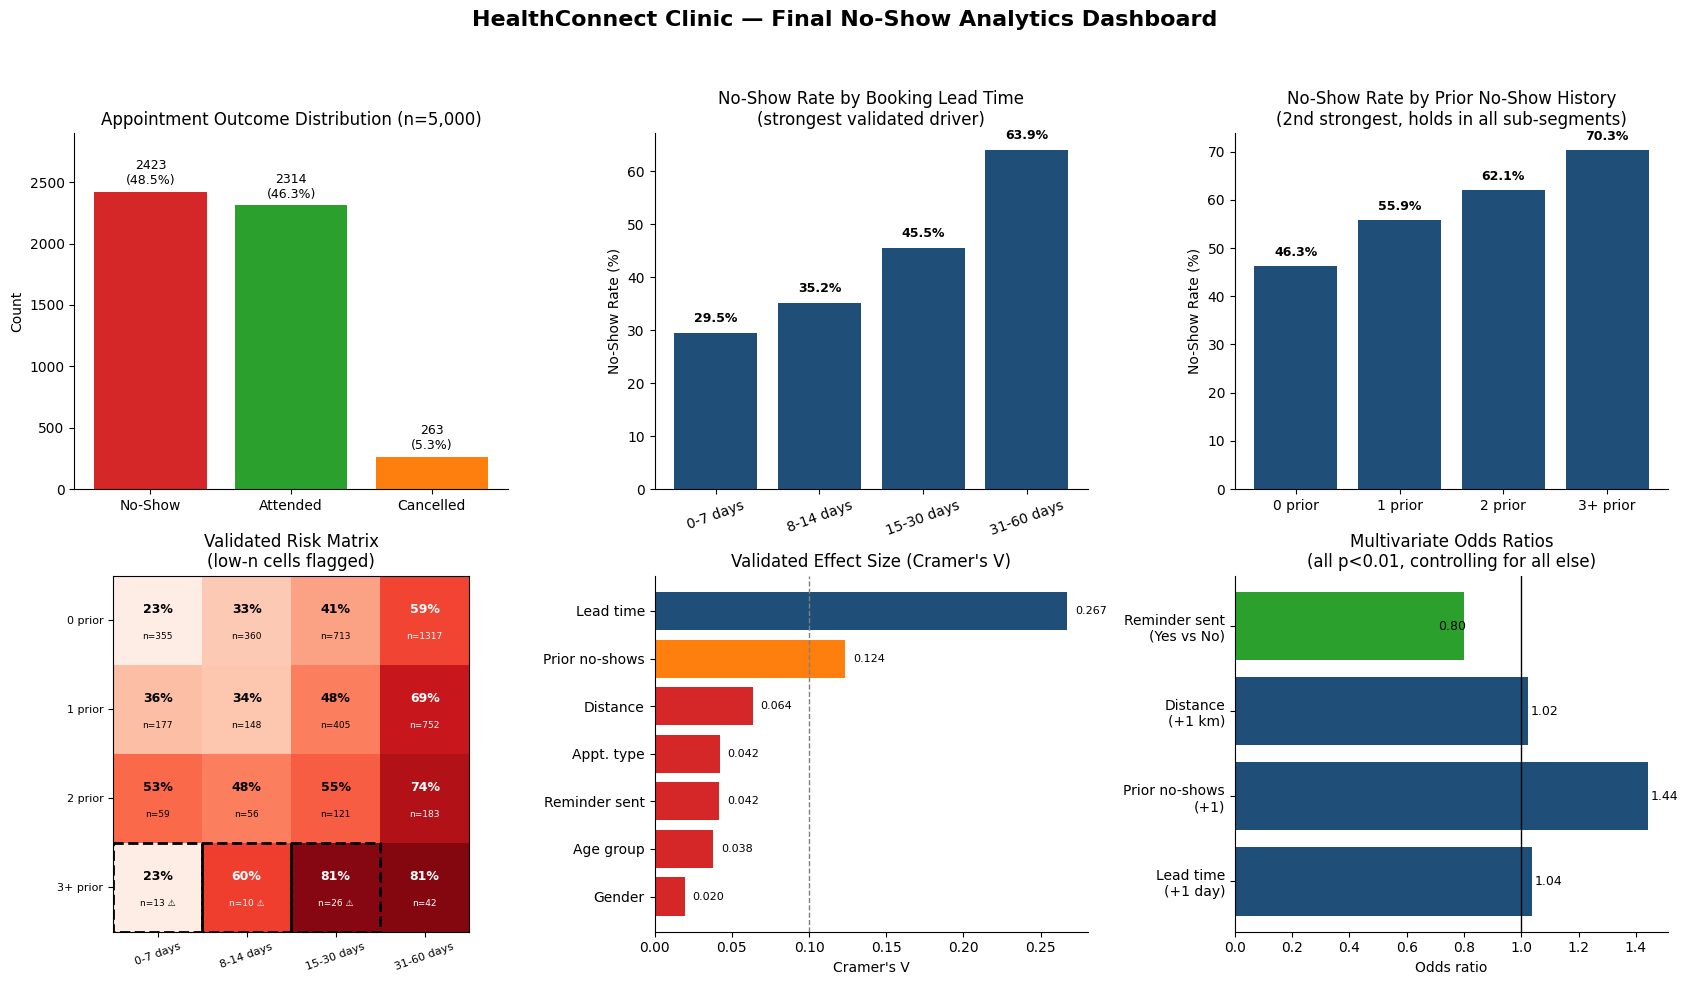

In [3]:
colors = {'primary': '#1f4e79', 'accent': '#d62728'}

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('HealthConnect Clinic — Final No-Show Analytics Dashboard', fontsize=16, fontweight='bold')

oc = df['appointment_outcome'].value_counts()
axes[0, 0].bar(oc.index, oc.values, color=['#d62728', '#2ca02c', '#ff7f0e'])
axes[0, 0].set_title('Appointment Outcome Distribution (n=5,000)')
axes[0, 0].set_ylim(0, 2900)
for i, v in enumerate(oc.values):
    axes[0, 0].text(i, v + 60, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)
axes[0, 0].set_ylabel('Count')

t = ans.groupby('lead_time_band', observed=True)['is_noshow'].mean() * 100
axes[0, 1].bar(t.index.astype(str), t.values, color=colors['primary'])
axes[0, 1].set_title('No-Show Rate by Booking Lead Time\n(strongest validated driver)')
axes[0, 1].set_ylabel('No-Show Rate (%)')
axes[0, 1].tick_params(axis='x', rotation=20)
for i, v in enumerate(t.values):
    axes[0, 1].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

t = ans.groupby('prior_noshow_band', observed=True)['is_noshow'].mean() * 100
axes[0, 2].bar(t.index.astype(str), t.values, color=colors['primary'])
axes[0, 2].set_title('No-Show Rate by Prior No-Show History\n(2nd strongest, holds in all sub-segments)')
axes[0, 2].set_ylabel('No-Show Rate (%)')
for i, v in enumerate(t.values):
    axes[0, 2].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

rate = ans.pivot_table(index='prior_noshow_band', columns='lead_time_band', values='is_noshow', aggfunc='mean', observed=True) * 100
count = ans.pivot_table(index='prior_noshow_band', columns='lead_time_band', values='is_noshow', aggfunc='count', observed=True)
im = axes[1, 0].imshow(rate.values, cmap='Reds', vmin=20, vmax=85)
axes[1, 0].set_xticks(range(4)); axes[1, 0].set_xticklabels(rate.columns, rotation=20, fontsize=8)
axes[1, 0].set_yticks(range(4)); axes[1, 0].set_yticklabels(rate.index, fontsize=8)
axes[1, 0].set_title('Validated Risk Matrix\n(low-n cells flagged)')
LOW_N = 30
for i in range(4):
    for j in range(4):
        v, n = rate.values[i, j], count.values[i, j]
        low_n = n < LOW_N
        c = 'white' if v > 55 else 'black'
        axes[1, 0].text(j, i - 0.12, f'{v:.0f}%', ha='center', va='center', color=c, fontsize=9, fontweight='bold')
        axes[1, 0].text(j, i + 0.18, f'n={int(n)}' + (' ⚠' if low_n else ''), ha='center', va='center', color=c, fontsize=6.5)
        if low_n:
            axes[1, 0].add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', linewidth=2, linestyle='--'))

segs = ['lead_time_band', 'prior_noshow_band', 'distance_band', 'reminder_sent', 'appointment_type', 'age_group', 'gender']
labels = ['Lead time', 'Prior no-shows', 'Distance', 'Reminder sent', 'Appt. type', 'Age group', 'Gender']
vals = [cramers_v(c) for c in segs]
order = np.argsort(vals)
bar_colors = ['#d62728' if v < 0.1 else ('#ff7f0e' if v < 0.2 else '#1f4e79') for v in np.array(vals)[order]]
axes[1, 1].barh(np.array(labels)[order], np.array(vals)[order], color=bar_colors)
axes[1, 1].axvline(0.1, color='grey', linestyle='--', linewidth=1)
axes[1, 1].set_title("Validated Effect Size (Cramer's V)")
axes[1, 1].set_xlabel("Cramer's V")
for i, v in enumerate(np.array(vals)[order]):
    axes[1, 1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)

mv_labels = ['Lead time\n(+1 day)', 'Prior no-shows\n(+1)', 'Distance\n(+1 km)', 'Reminder sent\n(Yes vs No)']
mv_or = [1.037, 1.441, 1.023, 0.801]
bar_colors2 = ['#1f4e79' if o > 1 else '#2ca02c' for o in mv_or]
axes[1, 2].barh(mv_labels, mv_or, color=bar_colors2)
axes[1, 2].axvline(1.0, color='black', linewidth=1)
axes[1, 2].set_title('Multivariate Odds Ratios\n(all p<0.01, controlling for all else)')
axes[1, 2].set_xlabel('Odds ratio')
for i, v in enumerate(mv_or):
    axes[1, 2].text(v + (0.01 if v > 1 else -0.09), i, f'{v:.2f}', va='center', fontsize=9)

for r in range(2):
    for c in range(3):
        if (r, c) in [(0, 0), (1, 0)]:
            continue
        axes[r, c].spines['top'].set_visible(False)
        axes[r, c].spines['right'].set_visible(False)
axes[0, 0].spines['top'].set_visible(False); axes[0, 0].spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('final_dashboard.png', dpi=150)
plt.show()

### 2.2b Final Dashboard — Power BI Build (Page 1: Executive Overview)

The dashboard has now also been built in Power BI Desktop from the same cleaned data (`HealthConnect_Appointment_Data_PowerBI_Ready.csv`, derived from the cleaned file above). Page 1 of the planned four pages is complete. This section does what Week 7 did for the Excel dashboard: it re-derives every figure on the page from the data in this notebook and checks it against what the dashboard displays, then tests the one chart whose pattern looked suspicious.

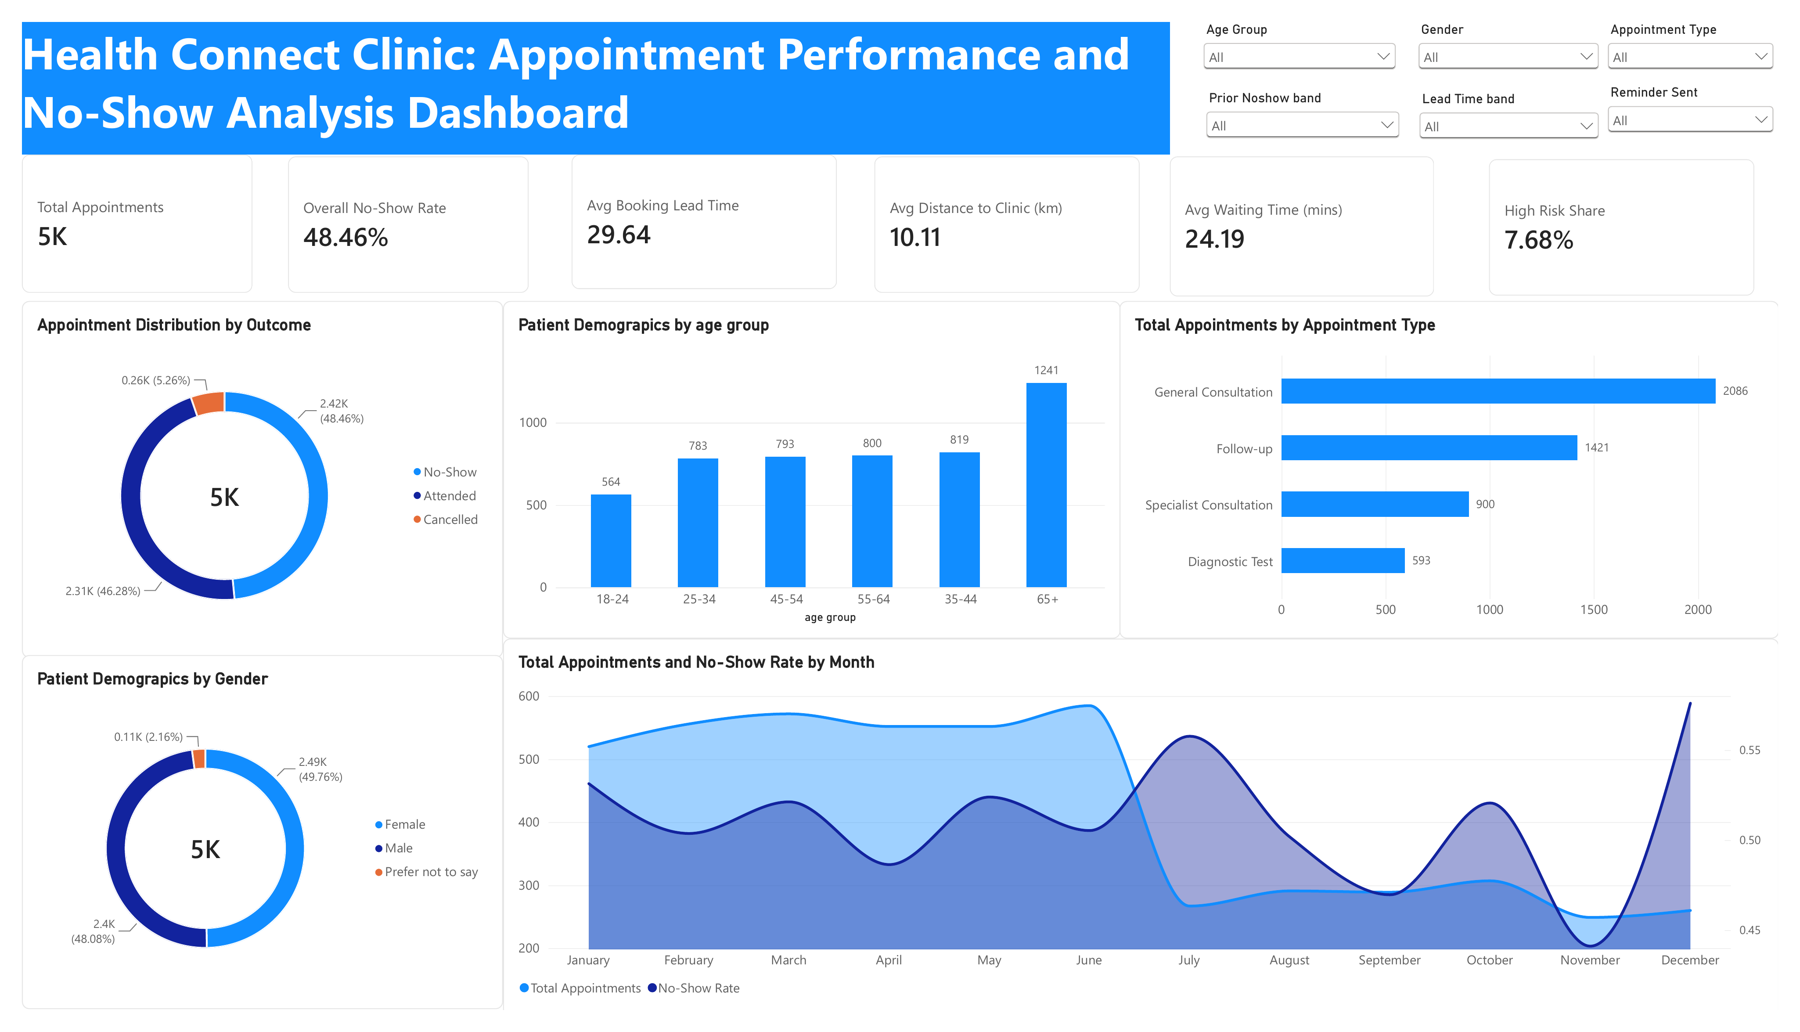

In [4]:
from IPython.display import Image, display
display(Image(filename='HealthConnect_PowerBI_Page1_Executive_Overview.png', width=900))

**Validation of dashboard figures.** Values on the left are read off the Power BI screenshot; values on the right are recomputed here.

In [5]:
dash = {
    'Total Appointments': (5000, len(df)),
    'Overall No-Show Rate (%)': (48.46, round((df['appointment_outcome'] == 'No-Show').mean() * 100, 2)),
    'Avg Booking Lead Time (days)': (29.64, round(df['booking_lead_days'].mean(), 2)),
    'Avg Distance to Clinic (km)': (10.11, round(df['distance_to_clinic_km'].mean(), 2)),
    'Avg Waiting Time (mins)': (24.19, round(df['waiting_time_minutes'].mean(), 2)),
    'High Risk Share (%, all records)': (7.68, round(((df['previous_no_shows'] >= 2) & (df['booking_lead_days'] >= 15)).mean() * 100, 2)),
    'No-Show count': (2423, int((df['appointment_outcome'] == 'No-Show').sum())),
    'Attended count': (2314, int((df['appointment_outcome'] == 'Attended').sum())),
    'Cancelled count': (263, int((df['appointment_outcome'] == 'Cancelled').sum())),
    'Female count': (2488, int((df['gender'] == 'Female').sum())),
    'Male count': (2404, int((df['gender'] == 'Male').sum())),
    'Prefer not to say count': (108, int((df['gender'] == 'Prefer not to say').sum())),
}
for k, v in {'General Consultation': 2086, 'Follow-up': 1421, 'Specialist Consultation': 900, 'Diagnostic Test': 593}.items():
    dash[f'Appt type: {k}'] = (v, int((df['appointment_type'] == k).sum()))
for k, v in {'18-24': 564, '25-34': 783, '35-44': 819, '45-54': 793, '55-64': 800, '65+': 1241}.items():
    dash[f'Age group: {k}'] = (v, int((df['age_group'] == k).sum()))

check = pd.DataFrame([{'Metric': k, 'Power BI shows': a, 'Recomputed': b, 'Result': 'PASS' if abs(a - b) < 0.006 else 'FAIL'}
                      for k, (a, b) in dash.items()])
print(f"{(check['Result'] == 'PASS').sum()} of {len(check)} checks passed")
check

22 of 22 checks passed


,Metric,Power BI shows,Recomputed,Result
0,Total Appointments,5000.00,5000.00,PASS
1,Overall No-Show Rate (%),48.46,48.46,PASS
2,Avg Booking Lead Time (days),29.64,29.64,PASS
3,Avg Distance to Clinic (km),10.11,10.11,PASS
4,Avg Waiting Time (mins),24.19,24.19,PASS
5,"High Risk Share (%, all records)",7.68,7.68,PASS
6,No-Show count,2423.00,2423.00,PASS
7,Attended count,2314.00,2314.00,PASS
8,Cancelled count,263.00,263.00,PASS
9,Female count,2488.00,2488.00,PASS


**High Risk Share: 7.68% here versus 7.9% elsewhere in this notebook.** Same segment (2+ prior no-shows AND 15+ day lead time), different denominator. Power BI flags it across all 5,000 records; the analysis in Sections 2.1–2.4 uses the Attended + No-Show base, where Cancelled appointments are excluded, as every no-show rate in this project does.

In [6]:
seg = (df['previous_no_shows'] >= 2) & (df['booking_lead_days'] >= 15)
base = df['appointment_outcome'].isin(['Attended', 'No-Show'])
print(f'All records:           {seg.sum()} / {len(df)} = {seg.mean()*100:.2f}%   (Power BI)')
print(f'Attended + No-Show:    {(seg & base).sum()} / {base.sum()} = {(seg & base).sum()/base.sum()*100:.2f}%   (notebook, Week 6-8)')

All records:           384 / 5000 = 7.68%   (Power BI)
Attended + No-Show:    372 / 4737 = 7.85%   (notebook, Week 6-8)


**Testing the "Appointments and No-Show Rate by Month" chart.** On the dashboard, volume is roughly 520–585 per month from January to June, then falls to roughly 250–310 from July onward, and the rate swings between about 44% and 58%. Before reading that as a trend, check what the chart is aggregating.

Appointment dates span: 2025-01-01 to 2026-06-30


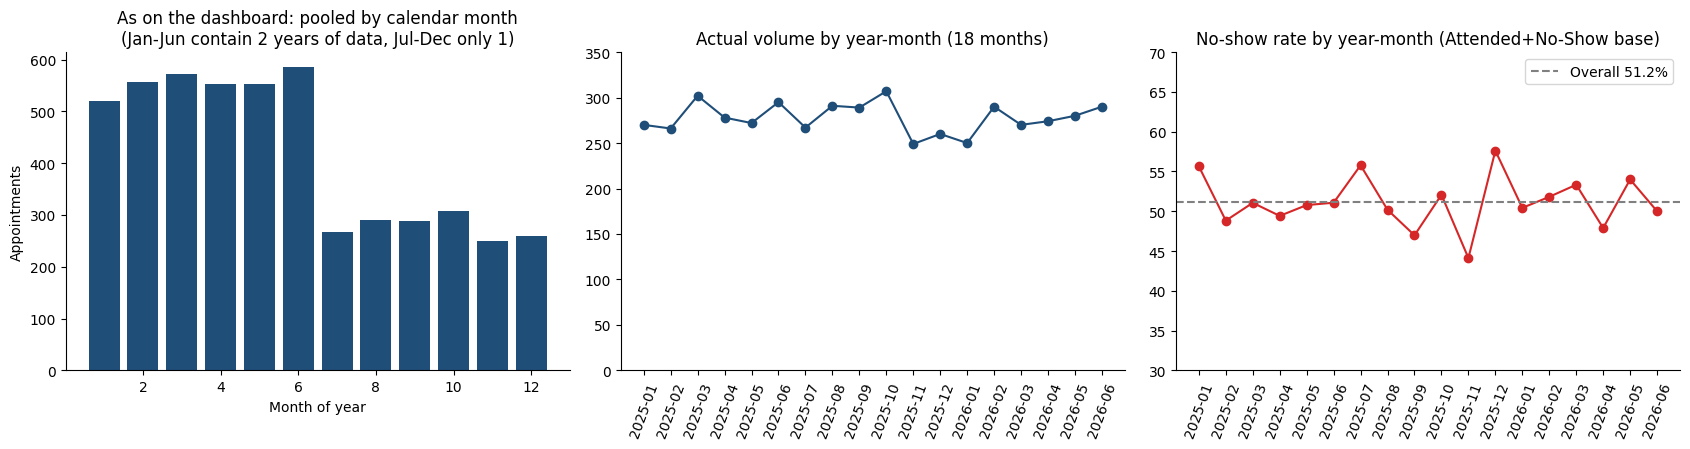

Is monthly no-show rate more than noise? chi-square across 18 year-months: p = 0.34 (dof=17)
Monthly rate range: 44.1% to 57.6%, typical monthly n = 277


In [7]:
from scipy import stats
d = df.copy()
d['appointment_date'] = pd.to_datetime(d['appointment_date'])
print('Appointment dates span:', d['appointment_date'].min().date(), 'to', d['appointment_date'].max().date())

d['month_of_year'] = d['appointment_date'].dt.month
d['year_month'] = d['appointment_date'].dt.to_period('M')
dbase = d[d['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
dbase['is_noshow'] = (dbase['appointment_outcome'] == 'No-Show').astype(int)

pooled = d.groupby('month_of_year').size()
actual = d.groupby('year_month').size()
rate_ym = dbase.groupby('year_month')['is_noshow'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
axes[0].bar(pooled.index, pooled.values, color='#1f4e79')
axes[0].set_title('As on the dashboard: pooled by calendar month\n(Jan-Jun contain 2 years of data, Jul-Dec only 1)')
axes[0].set_xlabel('Month of year'); axes[0].set_ylabel('Appointments')
axes[1].plot(actual.index.astype(str), actual.values, marker='o', color='#1f4e79')
axes[1].set_title('Actual volume by year-month (18 months)')
axes[1].tick_params(axis='x', rotation=70); axes[1].set_ylim(0, 350)
axes[2].plot(rate_ym.index.astype(str), rate_ym.values, marker='o', color='#d62728')
axes[2].axhline(dbase['is_noshow'].mean() * 100, color='grey', linestyle='--', label='Overall 51.2%')
axes[2].set_title('No-show rate by year-month (Attended+No-Show base)')
axes[2].tick_params(axis='x', rotation=70); axes[2].set_ylim(30, 70); axes[2].legend()
for ax in axes:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('month_chart_check.png', dpi=130); plt.show()

chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(dbase['year_month'], dbase['is_noshow']))
print(f'Is monthly no-show rate more than noise? chi-square across 18 year-months: p = {p:.2f} (dof={dof})')
print(f'Monthly rate range: {rate_ym.min():.1f}% to {rate_ym.max():.1f}%, typical monthly n = {int(actual.mean())}')

**Finding (a real weakness in the dashboard build, now documented):**

1. **The volume "drop" is an aggregation artifact, not a decline.** The data runs from January 2025 to June 2026, so January–June appear twice and July–December once when months are pooled by name. Real monthly volume is flat at roughly 250–305 appointments.
2. **The month-to-month no-show swings are consistent with noise.** Across the 18 year-months, the rate varies from about 44% to 58% on 250–300 records each, and the difference is not statistically significant (p ≈ 0.34). There is no upward or downward trend over the period either (2025: 51.1%, 2026: 51.2%).
3. **The chart's rate uses the Attended + No-Show base** (the 51.2% convention), while the Overall No-Show Rate card uses all records (48.46%). Both are legitimate, but the two should be labelled so a reader doesn't think they disagree.

**Fix to apply in Power BI:** build the axis from a Year-Month field (e.g. `FORMAT(appointment_date, "yyyy-MM")`, sorted by a date key) instead of month name, replace the smoothed area chart with a line or column chart, and title the rate series "No-show rate (Attended + No-Show)". Until then, do not present the July drop or the December spike as seasonal findings.

**Correction to earlier limitation wording:** this notebook previously said the dataset has "no explicit time boundary". That was wrong: appointment dates span Jan 2025 – Jun 2026. The dataset is long enough to check month-to-month stability (done above) but not to claim seasonality, since July–December is observed only once.

**Power BI build status.** Page 1 (Executive Overview) is built and its figures validated. Pages 2–4 (validated drivers; risk matrix and business impact; effect sizes and odds ratios) are specified in the Power BI build guide but not yet built. The key analytical findings (lead time, prior history, risk heatmap, effect sizes) are therefore currently shown only in the matplotlib dashboard in Section 2.2.

### 2.3 Final Business Insights

1. **Booking lead time is the strongest, most decision-relevant driver in this project.** No-show rate more than doubles from 29.5% to 63.9% across bands, confirmed with a moderate effect size (Cramér's V=0.267), significant in a multivariate model controlling for six other factors, and robust across 7 of 9 demographic subgroups tested.
2. **Prior no-show history is the single most consistent finding across the entire project.** It holds with zero exceptions across every appointment type tested, in addition to surviving multivariate control — the most dependable basis for a risk flag of anything examined.
3. **A specific, well-populated high-risk segment exists and is actionable now.** Patients with 2+ prior no-shows who book 15+ days ahead (7.9% of appointments, n=372) show a 69.1% no-show rate versus 51.2% overall — targeting this segment alone could recover an estimated ~67 appointment slots.
4. **Distance and reminder status are real but secondary levers.** Both are statistically independent effects confirmed in a multivariate model, but neither approaches the scale of lead time or prior history — they should complement, not replace, the top two actions.
5. **Appointment type, age, gender, day of week, and time of day are confirmed non-drivers.** This was tested three separate ways across Weeks 6-7 (effect size, multivariate significance, and segment stability) with consistent results — the clinic can safely deprioritise operational changes targeted at these dimensions.
6. **The analytical foundation itself is now verified trustworthy.** Every KPI and dashboard value has been independently recalculated and matched exactly; this is not a minor point — it is what makes the findings above safe to act on.


### 2.4 Final Recommendations

| Recommendation | Business action | Supporting evidence |
|---|---|---|
| Reconfirmation step for long-lead bookings | Automatic reconfirmation contact for appointments booked 15+ days out | Cramér's V=0.267; OR 1.037/day, p<0.001; robust across subgroups |
| Composite risk flag | Proactive staff follow-up for patients with 2+ prior no-shows AND 15+ day lead time | 69.1% vs 51.2% no-show rate; ~67 recoverable slots; well-populated (n=372) |
| Prior-no-show flag at booking | Simple booking-system flag for 2+ prior no-shows | Cramér's V=0.124; holds with zero exceptions across appointment types |
| Distance-based pilot | Transport support or telehealth follow-up for patients beyond ~20 km | Cramér's V=0.064; OR 1.023/km, p<0.001 |
| Maintain (don't expand) reminder programme | Keep current reminders; do not treat as primary lever | OR 0.80, p=0.002 — real but secondary effect |
| Escalate the Sunday-appointment discrepancy | Stakeholder review before further use in any model or report | ~15% of appointments fall on a day the Knowledge Base says the clinic is closed |


### 2.5 Final Analytical Limitations

- Findings describe **association, not proven causation** — particularly the reminder effect.
- The multivariate model's explanatory power is modest (pseudo R² ≈ 0.081) — useful for ranking driver importance, not for individual-patient risk scoring (that is the Data Science track's task).
- Several risk-matrix cells (n=10-26) remain **small-sample** and are flagged, not used, as the basis for any recommendation.
- The **Sunday-appointment discrepancy** (737 records, ~15%) remains unresolved pending stakeholder clarification and was excluded from all analysis.
- The dataset is a **single fictional extract covering Jan 2025 – Jun 2026 (18 months)** — long enough to check month-to-month stability (no trend found) but not to claim seasonality, since Jul–Dec is observed only once.
- No clinic-side operational data (staffing, slot capacity) is available, limiting how directly findings translate into a capacity-planning figure.


## 3. Final HC-POD Cross-Track Integration (Data Analytics → Data Science)

1. **Track collaborated with:** Data Science.
2. **Dependency:** the Data Science track's final model relies on the Data Analytics track's validated feature ranking to justify which predictors are worth including in a final, presentable model.
3. **Output received (conceptually, from Data Science's Week 7/8 process):** their commitment to test their candidate model on held-out data and report feature importance/interpretation for their final model — matching the same rigour standard applied here.
4. **Output provided:** the final, twice-validated feature-recommendation file (`HealthConnect_DataScience_Feature_Recommendations.csv`) — ranked by effect size, confirmed significant in a multivariate model, and confirmed to generalise on a 70/30 held-out split (Weeks 6-7), now finalised for their model documentation.
5. **Final integration activity completed:** cross-checked that the final KPI definitions (no-show vs cancelled treatment, band definitions) used in this notebook exactly match the definitions embedded in the feature-recommendation file, so any number the Data Science track quotes from Data Analytics is directly reproducible from this notebook.
6. **What changed:** the Data Science track can cite a single, final, consistent source of validated analytical findings in their own final documentation rather than reconciling three weeks of evolving figures.
7. **How the change improved the solution:** removes a subtle risk of the two tracks' final presentations quoting slightly different versions of "the no-show rate by lead time" — both tracks now point to the same final numbers.
8. **Evidence:** this notebook's Section 2.1 (Final Validated KPIs) and the finalised feature-recommendation CSV.
9. **Contribution to the final presentation:** the Data Analytics section of the final HC-POD presentation opens with these same final KPIs, so the audience sees one consistent narrative across the Data Analytics and Data Science sections rather than two versions of similar numbers.


## 4. Executive Summary (Non-Technical)

**The problem:** HealthConnect Clinic loses close to half of its scheduled appointments to no-shows.

**What the data shows:** two factors matter far more than any others. First, the longer a patient waits between booking and their appointment, the more likely they are to miss it — no-show rates more than double for appointments booked over a month ahead compared to those booked within a week. Second, a patient's own history is highly predictive — patients with several past no-shows are consistently more likely to miss future appointments too, and this holds true across every type of appointment we checked.

**Where to focus:** a specific, identifiable group of patients — those booking far ahead **and** with a history of missed appointments — make up under 8% of all appointments but account for a disproportionate share of no-shows. Targeting this group specifically, rather than broad clinic-wide measures, could recover an estimated 67 appointment slots in this dataset alone.

**What doesn't matter as much:** appointment type, patient age, gender, and the day or time of the appointment show little to no meaningful effect — checked three separate ways to be sure.

**What we're confident about:** every number in this report has been checked against the raw data and re-tested for reliability — this is not just a first look at the data, but a validated, stress-tested analysis.

**What's still open:** a data quirk showing appointments on Sundays (when the clinic states it is closed) needs clarification from clinic stakeholders before it's used in any further work.
